In [25]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing_extensions import TypedDict
from langgraph.graph import START,END
from langgraph.graph.state import StateGraph 
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
from langgraph.prebuilt import ToolNode , tools_condition
from typing import Annotated
from IPython.display import Image
load_dotenv()


True

In [ ]:
os.environ["LANGGRAPH_PROJECT"]="TestProject"

In [26]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"]="true"


In [27]:
llm = ChatGroq(
    model = "qwen/qwen3.8-27b",
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.2', 'langchain': '1.3.14'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x000001577F0B2710>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001577F0B3110>, model_name='qwen/qwen3.8-27b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [28]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]
    
@tool
def add(a : int, b:int):
    """add two numbers"""
    return a+b

tools = [add]
tool_node = ToolNode(tools)

llm_with_tools = llm.bind_tools(tools)

def call_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


In [39]:
config = {"thread_id": "1"}

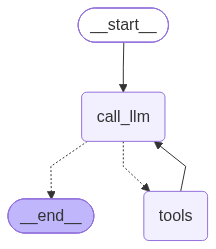

In [40]:
##graph creating
graph_builder = StateGraph(State)

##adding nodes
graph_builder.add_node("call_llm",call_llm)
graph_builder.add_node("tools",ToolNode(tools))

##adding edges
graph_builder.add_edge(START,"call_llm")
graph_builder.add_conditional_edges("call_llm",tools_condition)
graph_builder.add_edge("tools","call_llm")

memory = InMemorySaver()
graph = graph_builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [43]:
res = graph.invoke({"messages" : "what is 45 plus 563"},config=config)
res

{'messages': [HumanMessage(content='what is machine learning', additional_kwargs={}, response_metadata={}, id='7c70beb3-cfd6-4feb-8ecb-e692126b5ace'),
  AIMessage(content='Machine learning is a subset of artificial intelligence (AI) that focuses on building systems that can learn and improve from experience without being explicitly programmed.\n\nIn traditional programming, a developer writes specific rules and logic to process input data and produce an output. In machine learning, the process is reversed: the system is given large amounts of data and the desired output, and it uses statistical algorithms to identify patterns and create a model that can make predictions or decisions when presented with new data.\n\n**Key components of machine learning include:**\n\n1.  **Data:** The raw information used to train the model.\n2.  **Model:** The mathematical representation or algorithm that learns from the data.\n3.  **Training:** The process of feeding data into the model so it can adjus